In [19]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [21]:
df = pd.read_csv(
    "/content/IMDB Dataset.csv",
    encoding="utf-8",
    on_bad_lines="skip"
)

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
print(df.shape)
print(df.columns)

(50000, 2)
Index(['review', 'sentiment'], dtype='object')


In [23]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [24]:
df.isnull().sum()

,0
review,0
sentiment,0


In [25]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 418


In [26]:
df = df.drop_duplicates()

In [27]:
df.shape

(49582, 2)

In [28]:
df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [29]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    # Join words
    return ' '.join(words)

In [30]:
sample_review = df['review'].iloc[0]

print("Original Review:")
print(sample_review)

print("\nCleaned Review:")
print(preprocess_text(sample_review))

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [31]:
df['clean_review'] = df['review'].apply(preprocess_text)

In [32]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [33]:
X = df['clean_review']
y = df['sentiment']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39665,)
Testing data: (9917,)


In [35]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [36]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [37]:
X_test_tfidf = tfidf.transform(X_test)

In [38]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 50000)
Testing TF-IDF shape: (9917, 50000)


In [39]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred = model.predict(X_test_tfidf)

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8968438035696279


In [42]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8985018354995535


In [43]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive']
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [44]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4366  574]
 [ 449 4528]]


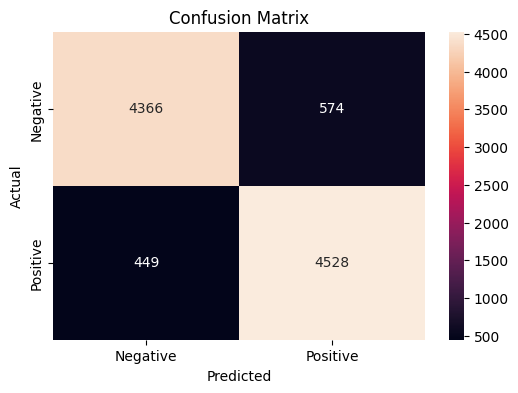

In [45]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [46]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = model.coef_[0]

In [47]:
positive_indices = np.argsort(coefficients)[-10:][::-1]

positive_words = feature_names[positive_indices]
positive_scores = coefficients[positive_indices]

print("Top 10 Positive Words:\n")

for word, score in zip(positive_words, positive_scores):
    print(f"{word}: {score:.4f}")

Top 10 Positive Words:

great: 8.3859
excellent: 7.1194
perfect: 5.4662
best: 5.3779
amazing: 5.0929
wonderful: 4.9892
favorite: 4.7204
loved: 4.6919
one best: 4.4219
fun: 4.4136


In [48]:
negative_indices = np.argsort(coefficients)[:10]

negative_words = feature_names[negative_indices]
negative_scores = coefficients[negative_indices]

print("Top 10 Negative Words:\n")

for word, score in zip(negative_words, negative_scores):
    print(f"{word}: {score:.4f}")

Top 10 Negative Words:

worst: -9.8358
bad: -8.9413
awful: -8.0631
boring: -7.0289
waste: -6.8138
poor: -6.3445
terrible: -6.1124
nothing: -5.9972
horrible: -5.1558
worse: -5.0798


In [49]:
positive_df = pd.DataFrame({
    'Word': positive_words,
    'Coefficient': positive_scores,
    'Sentiment': 'Positive'
})

negative_df = pd.DataFrame({
    'Word': negative_words,
    'Coefficient': negative_scores,
    'Sentiment': 'Negative'
})

top_words = pd.concat(
    [positive_df, negative_df],
    ignore_index=True
)

top_words

,Word,Coefficient,Sentiment
0,great,8.385878,Positive
1,excellent,7.119356,Positive
2,perfect,5.466155,Positive
3,best,5.377877,Positive
4,amazing,5.092859,Positive
5,wonderful,4.989228,Positive
6,favorite,4.720428,Positive
7,loved,4.691911,Positive
8,one best,4.421918,Positive
9,fun,4.413620,Positive


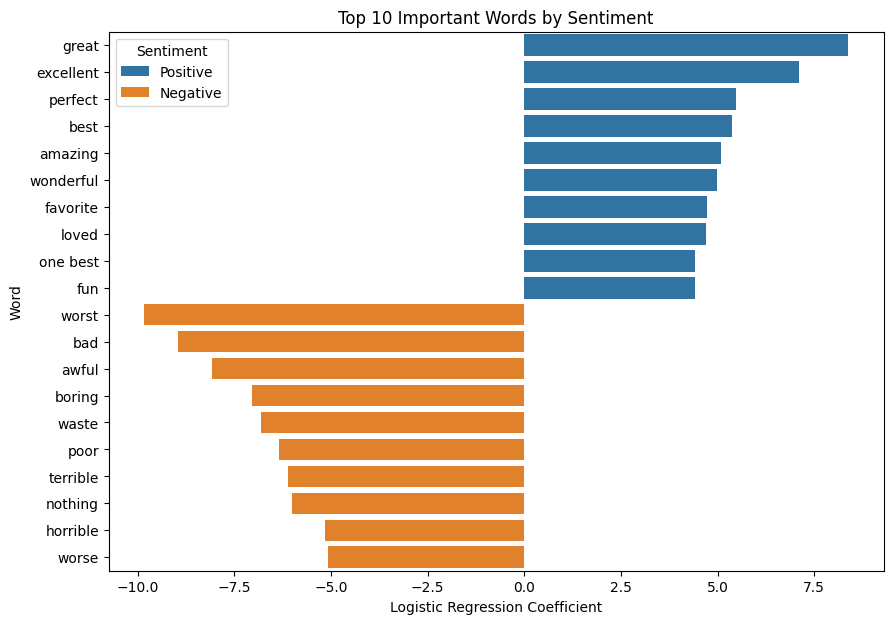

In [50]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    x='Coefficient',
    y='Word',
    hue='Sentiment'
)

plt.title('Top 10 Important Words by Sentiment')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Word')

plt.show()

In [51]:
new_reviews = [
    "This movie was absolutely fantastic and I loved every minute of it.",
    "This movie was terrible, boring and a complete waste of time."
]

In [52]:
clean_reviews = [
    preprocess_text(review)
    for review in new_reviews
]

clean_reviews

['movie absolutely fantastic loved every minute',
 'movie terrible boring complete waste time']

In [53]:
new_reviews_tfidf = tfidf.transform(clean_reviews)

In [54]:
predictions = model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: This movie was absolutely fantastic and I loved every minute of it.
Predicted Sentiment: Positive

Review: This movie was terrible, boring and a complete waste of time.
Predicted Sentiment: Negative

